# 12 — Shallow Networks: Representation, Sparsity, Convexity

**Mathematical Foundations of Control and Machine Learning — Winter 2026**

> **Central question.** *What can one hidden layer represent, and which part of its training becomes convex once its inner parameters are fixed?*

Part IV fuses control and learning. Before networks become dynamical systems, this notebook studies their static building block, one hidden layer. One observation organizes everything: the network is **nonlinear in the inner parameters but linear in the outer weights** — fixing the former turns training into convex optimization, and sparsity into linear programming.

### Table of Contents

1. **One hidden layer, three different objectives** — representation, approximation, regression
2. **Exact representation of finite data** — $N$ neurons suffice, constructively in 1-D
3. **Nonconvex in the inner parameters, convex in the outer weights**
4. **Sparse problems and linear programs** — $P_0$, $P_\varepsilon$, $P^{\rm reg}_\lambda$
5. **Laboratory: sparse shallow networks**
6. **Control ↔ ML**
7. **Common misconceptions**
8. **The dual of $P_0$ and its $L^\infty$ reading**
9. **Mean-field relaxation and the absence of a relaxation gap**
10. **Key takeaways**
11. **Exercises**

In [1]:
%matplotlib inline
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.optimize import linprog
import plotting as P           # the course palette, the house style, and the figure helpers

torch.manual_seed(0);

## Where are we?

> **Recap.** A network with one hidden layer is $\hat y(x)=\sum_j\omega_j\sigma(a_j\cdot x+b_j)$, its loss can be nonconvex, and every fitted model is judged with the train / validation / test protocol ([notebook 09](09_machine_learning_foundations_generalization.ipynb)). A linear cost on a polytope is minimized at a vertex, by dedicated algorithms.

We write a network as a map $f(x,\Theta)$ from a feature $x$ and parameters $\Theta$ (the *control*) to a prediction. **Local convention:** in this notebook the regularization weight $\lambda$ multiplies the *loss*, so a large $\lambda$ means *more* weight on the fit — the opposite of its usual role as the weight of a penalty.

## 1. One hidden layer, three different objectives

A **shallow network** with $P$ neurons and scalar output is
$$
f(x,\Theta)=\sum_{j=1}^P\omega_j\,\sigma(\langle a_j,x\rangle+b_j),\qquad\Theta=(\omega_j,a_j,b_j)_{j=1}^P,
$$
with activation $\sigma$; here $\sigma(z)=\max(0,z)$, the ReLU, and **outer weights** $\omega_j$. Given data $\{(x_i,y_i)\}_{i=1}^N$, three tasks must be distinguished:

- **exact representation:** $f(x_i,\Theta)=y_i$ for every $i$ (interpolation);
- **approximate representation:** $|f(x_i,\Theta)-y_i|\le\varepsilon$ for every $i$;
- **regression:** minimize $\frac1N\sum_i\ell(f(x_i,\Theta)-y_i)$ for a loss $\ell$.

A fourth, different question is the **approximation of a function** $g$ on a whole domain by networks of growing width, which is about $\sup_x|f(x,\Theta)-g(x)|$, not about finitely many points. Interpolating $N$ points says nothing about the values in between, and with noisy labels exact representation is usually *not* what one wants. These are distinct objectives, and results about one do not transfer automatically to another.

## 2. Exact representation of finite data

> **Finite-sample representation (Pinkus, 1999).**
> *Assumptions:* scalar output; $P\ge N$; $\sigma$ continuous and **not a polynomial**; the inputs $x_1,\dots,x_N$ are **distinct**.
>
> *Conclusion:* for every choice of labels $y_1,\dots,y_N$ there is $\Theta$ with $f(x_i,\Theta)=y_i$ for all $i$.
>
> *Interpretation:* with as many neurons as data points, one hidden layer can fit any labels exactly. An extension to vector outputs, with $(a_j,b_j)$ in a compact set, is proved by Liu and Zuazua (2025).

The hypothesis of **distinct inputs** cannot be dropped: if $x_1=x_2$ with $y_1\ne y_2$, no function can take both values at the same point. The ReLU is not a polynomial, so the result applies to it.

**A constructive proof in one dimension.** Sort the inputs, $x_1<\dots<x_N$, choose a knot $k_1<x_1$, set $k_{j}=x_{j-1}$ for $j=2,\dots,N$, and use the $N$ neurons $\sigma(x-k_j)$, with **no free constant or affine term**:
$$
f(x)=\sum_{j=1}^N\omega_j\,\sigma(x-k_j).
$$
At $x_i$, exactly the neurons with $k_j<x_i$, that is $j\le i$, are active. The interpolation conditions form a **lower-triangular** system, with diagonal entries $x_i-k_i>0$; it has a unique solution, computed by forward substitution. So $N$ neurons suffice, and the count is honest: the constant level at $x_1$ is produced by the first neuron, not by a free bias. Between the nodes the interpolant is piecewise linear, with kinks at the knots.

> **Predict.** For six points of the regression function $f(x)=\sin(2\pi x)\,e^{-x}$, what will the six neurons look like, and what will the interpolant do between the nodes?

In [2]:
# The point cloud and the regression data are drawn exactly as in notebook 09, so the data and splits are identical;
# a separate generator, untouched until the end, is reserved for the final evaluation.
X6 = torch.cat([torch.randn(60, 2) * 0.45 + torch.tensor([-0.6, 0.0]),
                torch.randn(60, 2) * 0.45 + torch.tensor([1.3, 0.3])]).numpy()
y6 = np.repeat([0.0, 1.0], 60)
rng = np.random.default_rng(0)
idx6 = rng.permutation(len(y6))
target9 = lambda t: np.sin(2 * np.pi * t) * np.exp(-t)           # the regression function
rng9 = np.random.default_rng(3)                                  # the regression data have their own stream
x9 = rng9.uniform(-1, 1, 60)
y9 = target9(x9) + 0.3 * rng9.standard_normal(60)
idx9 = rng9.permutation(60)
train9, val9, test9 = idx9[:36], idx9[36:48], idx9[48:]          # the test split is development data: not used
rng_eval = np.random.default_rng(12)                             # reserved stream for the final evaluation

relu = lambda z: np.maximum(z, 0.0)

knots: [-1.   -0.8  -0.5  -0.1   0.2   0.55] 
outer weights: [ 10.5831 -17.6385   5.4314   6.3849  -7.495    2.5607]
number of neurons: 6 for N = 6 points;  max |f(x_i) - y_i| = 4.0e-15


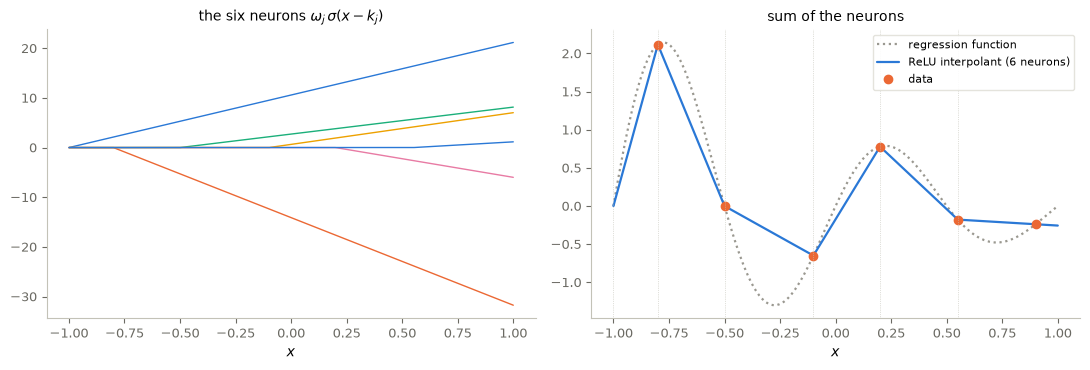

In [3]:
x_small = np.array([-0.8, -0.5, -0.1, 0.2, 0.55, 0.9])
y_small = target9(x_small)
knots_small = np.concatenate([[-1.0], x_small[:-1]])             # k_1 < x_1, then k_j = x_{j-1}
A_small = relu(np.subtract.outer(x_small, knots_small))          # lower triangular, positive diagonal
w_small = np.linalg.solve(A_small, y_small)                      # forward substitution
f_small = lambda t: relu(np.subtract.outer(t, knots_small)) @ w_small
print("knots:", knots_small, "\nouter weights:", np.round(w_small, 4))
print(f"number of neurons: {len(w_small)} for N = {len(x_small)} points;  "
      f"max |f(x_i) - y_i| = {np.abs(f_small(x_small) - y_small).max():.1e}")

grid = np.linspace(-1, 1, 400)
fig, (ax1, ax2) = P.panels(2, figsize=(11.0, 3.8))
for k, w in zip(knots_small, w_small):
    ax1.plot(grid, w * relu(grid - k), lw=1)
P.label(ax1, "$x$", title=r"the six neurons $\omega_j\,\sigma(x-k_j)$")
ax2.plot(grid, target9(grid), color=P.GREY, ls=":", label="regression function")
ax2.plot(grid, f_small(grid), color=P.BLUE, label="ReLU interpolant (6 neurons)")
ax2.plot(x_small, y_small, "o", color=P.ORANGE, label="data")
for k in knots_small:
    ax2.axvline(k, color=P.RULE, lw=0.5, ls=":")
P.label(ax2, "$x$", title="sum of the neurons")
plt.show()

**Figure 1.** The constructive 1-D representation with $N=6$ points of the regression function. *Left:* the six weighted neurons $\omega_j\sigma(x-k_j)$; the first knot is $k_1=-1$, the others are the first five data points. *Right:* their sum, the data and the knots (dotted).

*Interpretation (answer to the prediction).* Each neuron is a ramp that starts at its knot; their sum is the piecewise-linear interpolant through the six points, exact at every node (printed error at rounding level), with $N=6$ neurons and no free constant. Between nodes the network joins the data by straight segments, and to the left of $x_1$ it is a single ramp: exact representation of finite data says nothing about the function elsewhere.

## 3. Nonconvex in the inner parameters, convex in the outer weights

Training *all* parameters $\Theta$ is a nonconvex problem: relabelling two neurons gives two global minimizers whose midpoint can be strictly worse, and even the set of exact interpolants $\{\Theta:\ f(x_i,\Theta)=y_i\ \forall i\}$ is nonconvex. The source of the nonconvexity is the product $\omega_j\,\sigma(\langle a_j,x\rangle+b_j)$.

Now **fix the inner parameters** on a finite dictionary $(a_j,b_j)_{j=1}^P$, and write $F_{ij}=\sigma(\langle a_j,x_i\rangle+b_j)$. The predictions on the data are $F\omega$, **linear** in $\omega$. Any convex loss of $F\omega-y$, plus any convex penalty on $\omega$, is then a convex function of $\omega$, and exact interpolation is the linear constraint $F\omega=y$. This is the first numerical scheme for these problems: discretize the parameter set and solve a convex program.

Two cautions belong to this step.

- **A global optimum on the dictionary is not a global optimum over all networks.** The convex problem only searches among networks whose neurons belong to the dictionary. Its optimal value is at least the value over all parameters in the continuous set, and in general larger.
- **The dictionary must allow what is asked.** Exact interpolation of arbitrary labels needs $\operatorname{rank}F=N$. An arbitrary grid can fail this, for instance if no neuron is active at some data point. In the laboratory we check the rank, and report infeasibility if it occurs.

## 4. Sparse problems and linear programs

The number of active neurons is $\|\omega\|_{\ell^0}$, which is nonconvex; we replace it by $\|\omega\|_{\ell^1}$, as in compressed sensing, under the principle that sparsity mitigates overfitting. With a compact parameter set $\Omega\subset\mathbb R^{d+1}$, the three sparse problems are
$$
(P_0)\quad\inf_\Theta\|\omega\|_{\ell^1}\ \text{ s.t. } f(x_i,\Theta)=y_i\ \forall i;\qquad
(P_\varepsilon)\quad\inf_\Theta\|\omega\|_{\ell^1}\ \text{ s.t. } |f(x_i,\Theta)-y_i|\le\varepsilon\ \forall i;
$$
$$
(P^{\rm reg}_\lambda)\quad\inf_\Theta\ \|\omega\|_{\ell^1}+\frac{\lambda}{N}\sum_{i=1}^N\ell\big(f(x_i,\Theta)-y_i\big).
$$
**Read the convention carefully.** $\lambda$ multiplies the *loss*: a large $\lambda$ gives *more* weight to the fit and less to sparsity, and $\lambda\to\infty$ approaches interpolation. It is not the problem "loss $+\lambda\|\omega\|_1$", where a large $\lambda$ means strong regularization.

**As linear programs, on a fixed dictionary.** Write $\omega=\omega^+-\omega^-$ with $\omega^\pm\ge0$, so that $\|\omega\|_1=\mathbf 1^\top(\omega^++\omega^-)$ at an optimum.

- $P_0$ becomes: minimize $\mathbf 1^\top(\omega^++\omega^-)$ subject to $F(\omega^+-\omega^-)=y$, $\omega^\pm\ge0$.
- For $P^{\rm reg}_\lambda$ we **choose the absolute loss** $\ell(r)=|r|$ and add variables $t_i\ge|F\omega-y|_i$: minimize $\mathbf 1^\top(\omega^++\omega^-)+\frac\lambda N\mathbf 1^\top t$ subject to $-t\le F(\omega^+-\omega^-)-y\le t$. This choice is pedagogical: the squared loss with an $\ell^1$ penalty is also convex, but it is not a linear program.

**Which sparsity statements hold?** $P_0$ on a dictionary is a linear program in standard form with $N$ equality constraints. A *basic* (vertex) feasible solution has at most $N$ nonzero variables, and at an optimum $\omega_j^+$ and $\omega_j^-$ are not both positive, so **a vertex solution of $P_0$ uses at most $N$ neurons.** The dual simplex method returns such a vertex; an interior-point method may not. Degeneracy can give fewer than $N$. We count the support with a relative tolerance $10^{-9}$, and we make **no** such claim for the regularized problem, whose vertices are counted against $2N$ inequality constraints.

> **Predict.** On the 36 training samples of the regression data, how many neurons will $P_0$ use, and how will the number of active neurons of $P^{\rm reg}_\lambda$ change as $\lambda$ grows?

## 5. Laboratory: sparse shallow networks

**Protocol** (fixed in advance, before the final-evaluation data were generated). The data are the one-dimensional regression data of notebook 09: 60 samples $y_i=f(x_i)+\text{noise}$, with $x_i$ uniform on $[-1,1]$ and noise of standard deviation $0.3$, with the same training split (36 samples) and validation split (12). Their 12-sample test split was already exposed during earlier model development and is not used.

- **Dictionary, built from training inputs only:** ReLU neurons $\sigma(\pm(x-k))$ with knots $k$ at the 36 training inputs and at 25 equally spaced points of $[-1.2,1.2]$. The knots at the training inputs make exact interpolation possible; the rank is checked.
- **Procedures:** $P_0$ (exact interpolation of the training data) and $P^{\rm reg}_\lambda$ with absolute loss for $\lambda\in\{1,3,10,30,100,300,1000,3000,10000\}$.
- **Selection:** $\lambda$ with the smallest validation mean absolute error (ties to the smaller $\lambda$).
- **Final evaluation:** 500 new samples from the same law, drawn from the reserved generator, once, for $P_0$ and for the selected $P^{\rm reg}_\lambda$, reported side by side.

dictionary: 122 neurons;  rank of the 36 x 122 feature matrix = 36 (exact interpolation needs 36)
P0: ||omega||_1 = 944.2,  active neurons 36 (vertex bound N = 36),  max interpolation error 1.5e-13
 lambda   active neurons   training MAE   validation MAE   ||omega||_1
      1                0          0.861            0.926         0.00
      3                0          0.861            0.926         0.00
     10                1          0.854            0.927         0.05
     30                2          0.804            0.860         1.11
    100                8          0.307            0.544        31.33
    300                8          0.223            0.406        46.55
   1000               15          0.160            0.291        81.63
   3000               23          0.086            0.524       234.90
  10000               34          0.012            0.579       731.43
selected lambda (validation): 1000   P0 validation MAE: 0.575


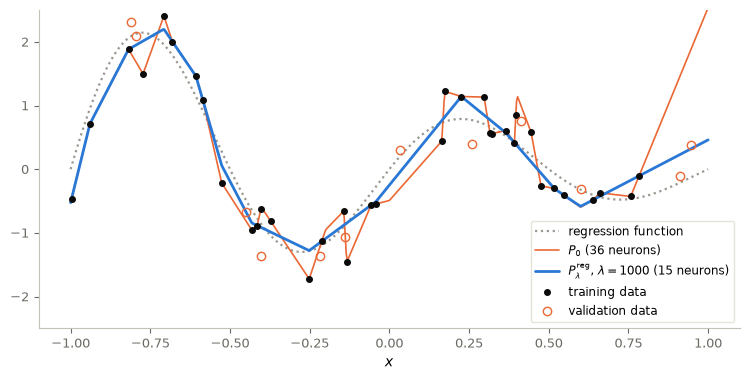

In [4]:
x_tr, y_tr, x_val, y_val = x9[train9], y9[train9], x9[val9], y9[val9]
knots = np.unique(np.concatenate([x_tr, np.linspace(-1.2, 1.2, 25)]))
a_dict = np.concatenate([np.ones_like(knots), -np.ones_like(knots)])      # neurons relu(+(x - k)) and relu(-(x - k))
b_dict = np.concatenate([-knots, knots])
features = lambda x: relu(np.multiply.outer(x, a_dict) + b_dict)
F_tr, F_val = features(x_tr), features(x_val)
support = lambda om: np.where(np.abs(om) > 1e-9 * max(1.0, np.abs(om).max()))[0]
print(f"dictionary: {F_tr.shape[1]} neurons;  rank of the {F_tr.shape[0]} x {F_tr.shape[1]} feature matrix = "
      f"{np.linalg.matrix_rank(F_tr)} (exact interpolation needs {len(y_tr)})")

def l1_exact_lp(F, y):
    # P0 on the dictionary: min 1'(w+ + w-) s.t. F (w+ - w-) = y, by the dual simplex (returns a vertex)
    n, p = F.shape
    res = linprog(np.ones(2 * p), A_eq=np.hstack([F, -F]), b_eq=y, method="highs-ds")
    assert res.status == 0, res.message
    return res.x[:p] - res.x[p:], res.eqlin.marginals, res.fun

def l1_regression_lp(F, y, lam):
    # P^reg_lambda, absolute loss: min 1'(w+ + w-) + (lam/n) 1't  s.t.  -t <= F (w+ - w-) - y <= t
    n, p = F.shape
    c = np.concatenate([np.ones(2 * p), lam / n * np.ones(n)])
    A_ub = np.block([[np.hstack([F, -F]), -np.eye(n)], [np.hstack([-F, F]), -np.eye(n)]])
    res = linprog(c, A_ub=A_ub, b_ub=np.concatenate([y, -y]), method="highs-ds")
    assert res.status == 0, res.message
    return res.x[:p] - res.x[p:2 * p], res.fun

omega_P0, dual_P0, value_P0 = l1_exact_lp(F_tr, y_tr)
support_P0 = support(omega_P0)
if y_tr @ dual_P0 < 0:
    dual_P0 = -dual_P0                                           # fix the solver's sign convention for the duals
print(f"P0: ||omega||_1 = {value_P0:.1f},  active neurons {len(support_P0)} (vertex bound N = {len(y_tr)}),  "
      f"max interpolation error {np.abs(F_tr @ omega_P0 - y_tr).max():.1e}")

lam_grid = [1, 3, 10, 30, 100, 300, 1000, 3000, 10000]
omegas = {lam: l1_regression_lp(F_tr, y_tr, lam)[0] for lam in lam_grid}   # TRAINING data only
val_mae = {lam: float(np.mean(np.abs(F_val @ om - y_val))) for lam, om in omegas.items()}   # VALIDATION only
selected_lam = min(lam_grid, key=lambda lam: (val_mae[lam], lam))
print(" lambda   active neurons   training MAE   validation MAE   ||omega||_1")
for lam in lam_grid:
    om = omegas[lam]
    print(f"{lam:7d}   {len(support(om)):14d}   {np.mean(np.abs(F_tr @ om - y_tr)):12.3f}   "
          f"{val_mae[lam]:14.3f}   {np.abs(om).sum():10.2f}")
print("selected lambda (validation):", selected_lam,
      f"  P0 validation MAE: {np.mean(np.abs(F_val @ omega_P0 - y_val)):.3f}")

grid = np.linspace(-1, 1, 600)
fig, ax = P.panels(figsize=(7.6, 3.9))
ax.plot(grid, target9(grid), color=P.GREY, ls=":", label="regression function")
ax.plot(grid, features(grid) @ omega_P0, color=P.ORANGE, lw=1.2, label=f"$P_0$ ({len(support_P0)} neurons)")
ax.plot(grid, features(grid) @ omegas[selected_lam], color=P.BLUE, lw=2,
        label=rf"$P^{{\rm reg}}_\lambda$, $\lambda={selected_lam}$ ({len(support(omegas[selected_lam]))} neurons)")
ax.plot(x_tr, y_tr, "o", color=P.INK, ms=4, label="training data")
ax.plot(x_val, y_val, "o", mfc="none", color=P.ORANGE, ms=6, label="validation data")
P.label(ax, "$x$", ylim=(-2.5, 2.5), legend={"fontsize": 8.5, "loc": "lower right"})
plt.show()

**Figure 2.** Sparse shallow ReLU networks on the regression training data: the exact-interpolation solution of $P_0$ and the regularized solution $P^{\rm reg}_\lambda$ (absolute loss) at the $\lambda$ chosen on the validation set, with training and validation data. Both curves are piecewise linear, with kinks at their active knots.

*Interpretation (answer to the prediction).* $P_0$ uses as many neurons as the printed count, at most $N=36$ as the vertex argument guarantees, and interpolates every training point, noise included: its $\ell^1$ norm is large, because passing through closely spaced noisy points needs large slopes. The regularized solution uses far fewer neurons and follows the smooth trend, at the price of a training error. On these data, interpolating the noisy labels gave a larger validation error than the regularized fit (see the printed table). Exact interpolation does not, by itself, prove poor prediction, but here it did not pay. Sparsity, by itself, is not a guarantee of a good model either.

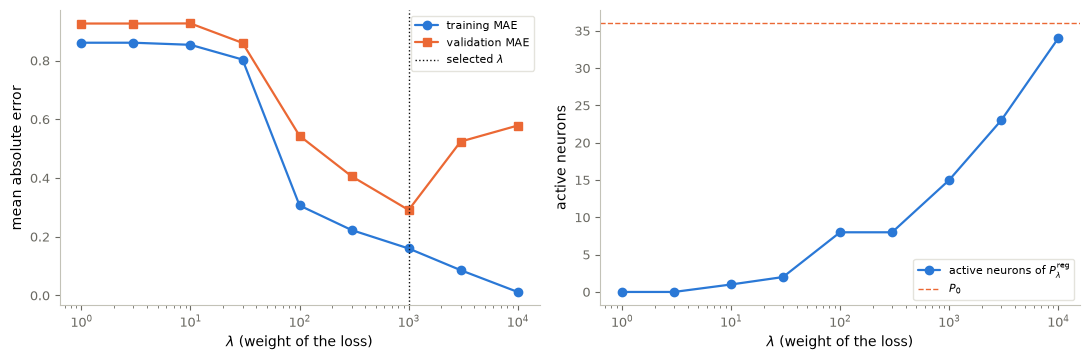

In [5]:
fig, (ax1, ax2) = P.panels(2, figsize=(11.0, 3.7))
ax1.semilogx(lam_grid, [np.mean(np.abs(F_tr @ omegas[l] - y_tr)) for l in lam_grid], "o-", color=P.BLUE, label="training MAE")
ax1.semilogx(lam_grid, [val_mae[l] for l in lam_grid], "s-", color=P.ORANGE, label="validation MAE")
ax1.axvline(selected_lam, color=P.INK, ls=":", lw=1, label="selected $\\lambda$")
P.label(ax1, r"$\lambda$ (weight of the loss)", "mean absolute error")
ax2.semilogx(lam_grid, [len(support(omegas[l])) for l in lam_grid], "o-", color=P.BLUE, label=r"active neurons of $P^{\rm reg}_\lambda$")
ax2.axhline(len(support_P0), color=P.ORANGE, ls="--", lw=1, label=r"$P_0$")
P.label(ax2, r"$\lambda$ (weight of the loss)", "active neurons")
plt.show()

**Figure 3.** The path of $P^{\rm reg}_\lambda$ (absolute loss) on the regression data. *Left:* training and validation mean absolute errors against $\lambda$, with the selected value. *Right:* the number of active neurons, compared with $P_0$.

*Interpretation (answer to the prediction).* In this notebook's convention a larger $\lambda$ gives more weight to the fit: the training error decreases. This is a general fact for optimal solutions: increasing $\lambda$ can never increase the optimal loss term, nor decrease the optimal $\|\omega\|_1$ (compare the objectives of two optimal solutions, as in Exercise 2). The number of active neurons grows **in this table**, from $0$ for small $\lambda$ (where $\omega=0$ is optimal) towards the interpolation regime. That growth is an observation here, not a guaranteed monotonicity. The validation error is smallest at an intermediate value, which is selected. Validation, not sparsity alone and not the training error, decides; and the final evaluation below reports the two procedures on new data.

In [6]:
# Final evaluation, as fixed in the protocol: 500 new samples from the reserved generator,
# evaluated once for each procedure. No choice depends on these numbers.
x_eval = rng_eval.uniform(-1, 1, 500)
y_eval = target9(x_eval) + 0.3 * rng_eval.standard_normal(500)
F_eval = features(x_eval)
for name, om in (("P0 (exact interpolation)", omega_P0), (f"P_reg, lambda = {selected_lam}", omegas[selected_lam])):
    r = F_eval @ om - y_eval
    print(f"{name:28s} final MAE {np.mean(np.abs(r)):.3f}   final MSE {np.mean(r**2):.3f}")

P0 (exact interpolation)     final MAE 0.470   final MSE 0.450
P_reg, lambda = 1000         final MAE 0.308   final MSE 0.148


## 6. Control ↔ ML

- **A neuron is the vector field of a neural ODE.** **DIRECT CONNECTION.** The neural ODE $x'=w(t)\sigma(a(t)\cdot x+b(t))$, its Euler scheme (a residual network) and the shallow network $\sum_j\omega_j\sigma(a_j\cdot x+b_j)$ are the same expression read three ways.
- **$\ell^1$ on the weights, $L^\infty$ on the dual.** **MATHEMATICAL ANALOGY.** The dual of $P_0$ (§8) bounds the correlation of every neuron with a dual vector by $1$, and the active neurons are those that reach the bound. Bang-bang control shows the same pairing: the control of minimal $L^\infty$ norm is obtained through an $L^1$-type dual functional. Similar structure, different spaces.
- **Choosing the regularization on validation data.** **DIRECT CONNECTION**: $\lambda$ plays the role of the degree in polynomial regression.

## 7. Common misconceptions

**"The LP gives the best shallow network."** It gives the best network *among those whose neurons lie in the dictionary*. Refining the dictionary changes the answer; the continuous problem is a different one (§3, §9).

**"Every solver returns at most $N$ neurons."** The bound holds for vertex solutions of $P_0$; another solver may return a non-vertex optimum, and no such bound was claimed for $P^{\rm reg}_\lambda$ (§4).

**"A large $\lambda$ means strong regularization."** Not in this notebook's convention, where $\lambda$ multiplies the loss (§4, Figure 3).

**"With $N$ neurons any data can be fitted."** Only if the inputs are distinct (§2); and fitting noisy labels exactly can generalize badly: on the regression data it did worse on validation than the regularized fit (Figure 2), although interpolation alone does not prove poor prediction.

## 8. The dual of $P_0$ and its $L^\infty$ reading

The linear program $P_0$ on a dictionary, $\min\|\omega\|_1$ subject to $F\omega=y$, has the dual
$$
\max_{c\in\mathbb R^N}\ y^\top c\qquad\text{subject to}\qquad|F^\top c|_\infty\le1,\ \text{ i.e. }\ \Big|\sum_ic_i\,\sigma(\langle a_j,x_i\rangle+b_j)\Big|\le1\ \text{ for every neuron }j.
$$
*(Weak duality: for feasible $\omega$ and $c$, $y^\top c=\omega^\top F^\top c\le\|\omega\|_1|F^\top c|_\infty\le\|\omega\|_1$; strong duality holds for feasible linear programs.)* The dual vector $c$ assigns a weight to each data point. Every neuron's correlation with these weights is at most $1$ in absolute value, and **complementary slackness** says that a neuron can be active only if its correlation equals $\pm1$, with the sign of its weight. Choosing neurons is therefore deciding which correlations saturate, a discrete analogue of the switching structure of bang-bang controls.

The cell below takes the multipliers returned by the solver for the laboratory problem and checks strong duality, dual feasibility and complementary slackness.

primal value 944.216885, dual value y.c = 944.216885;  max |F^T c| = 1.0000000000
active neurons with |correlation| = 1 (to 1e-8): 36 of 36;  sign agreement: True
sum_i c_i = 9.2e-14,  sum_i c_i x_i = 4.3e-14  (their combination is the gap between the two orientations)


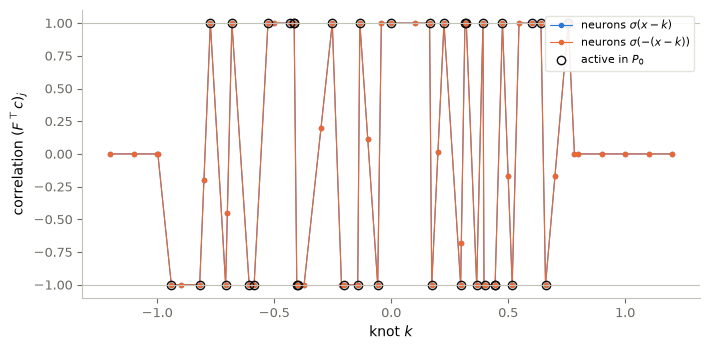

In [7]:
corr = F_tr.T @ dual_P0
print(f"primal value {value_P0:.6f}, dual value y.c = {y_tr @ dual_P0:.6f};  max |F^T c| = {np.abs(corr).max():.10f}")
print(f"active neurons with |correlation| = 1 (to 1e-8): "
      f"{np.sum(np.abs(np.abs(corr[support_P0]) - 1) < 1e-8)} of {len(support_P0)};  "
      f"sign agreement: {bool(np.all(np.sign(corr[support_P0]) == np.sign(omega_P0[support_P0])))}")
print(f"sum_i c_i = {dual_P0.sum():.1e},  sum_i c_i x_i = {dual_P0 @ x_tr:.1e}"
      "  (their combination is the gap between the two orientations)")
n_k = len(knots)
fig, ax = P.panels(figsize=(7.2, 3.6))
ax.plot(knots, corr[:n_k], ".-", color=P.BLUE, lw=0.8, label=r"neurons $\sigma(x-k)$")
ax.plot(knots, corr[n_k:], ".-", color=P.ORANGE, lw=0.8, label=r"neurons $\sigma(-(x-k))$")
ax.plot(np.concatenate([knots, knots])[support_P0], corr[support_P0], "o", mfc="none", color=P.INK, label="active in $P_0$")
ax.axhline(1, color=P.RULE, lw=0.8); ax.axhline(-1, color=P.RULE, lw=0.8)
P.label(ax, "knot $k$", r"correlation $(F^\top c)_j$")
plt.show()

**Figure 4.** The dual certificate of $P_0$ on the laboratory problem: the correlation $(F^\top c)_j$ of every neuron of the dictionary with the dual vector returned by the solver, plotted against the knot, for the two orientations of the ReLU; circles mark the neurons active in the primal solution.

*Interpretation.* All correlations lie in $[-1,1]$ (dual feasibility), and every active neuron sits exactly on $\pm1$ with the sign of its weight (complementary slackness), as printed; the primal and dual values coincide. Since $\sigma(z)-\sigma(-z)=z$, the correlations of the two orientations at the same knot differ by $\sum_ic_i(x_i-k)$, an affine function of $k$; the printed sums measure that gap for this dual solution. The certificate proves optimality *on this dictionary*, nothing more.

## 9. Mean-field relaxation and the absence of a relaxation gap

Replacing the finite sum by an integral against a signed measure, $\int_\Omega\sigma(\langle a,x\rangle+b)\,d\mu(a,b)$, makes the network **linear in $\mu$**, and the cost $\|\omega\|_{\ell^1}$ becomes the total variation $\|\mu\|_{\rm TV}$. The relaxed problems $(PR_0)$, $(PR_\varepsilon)$, $(PR^{\rm reg}_\lambda)$ are convex.

> **Theorem (Liu and Zuazua, 2025).** *Assumptions:* $\sigma$ is continuous, with $\sigma(z)=0$ for $z\le0$ and $\sigma(z)>0$ for $z>0$; $\Omega$ is compact and contains a ball centred at $0$; $P\ge N$.
>
> *Conclusion:* the values of $P_0$, $P_\varepsilon$, $P^{\rm reg}_\lambda$ equal those of their relaxations, and the extreme points of the relaxed solution sets are sums of $N$ Dirac masses, $\mu^*=\sum_{j=1}^N\omega_j^*\delta_{(a_j^*,b_j^*)}$.

The ReLU satisfies the assumption on $\sigma$. **This equality concerns the continuous parameter set $\Omega$.** Our dictionary is a finite subset of parameters, which is not such an $\Omega$ (it contains no ball), so the theorem does not say that the discretized problem has the same value; refining the dictionary approaches the continuous problem only under further arguments not given here. For heavily overlapping data a choice $\lambda\sim N^{1/d}$ in $P^{\rm reg}_\lambda$ has been suggested; this is a recommendation in that context, not a universal law, and in this notebook $\lambda$ was chosen on validation data. The second numerical scheme — SGD on over-parametrized networks with sparsification, in the mean-field regime of Chizat and Bach (2018) — avoids the curse of dimension of grids but lacks global guarantees.

## 10. Key takeaways

1. Approximation of functions, exact representation of finite data and regression are different objectives.
2. With distinct inputs, $P\ge N$ and a non-polynomial activation, one hidden layer interpolates any labels; in 1-D, $N$ ReLU neurons do it by a triangular system, with no free bias.
3. Fixing the inner parameters makes the network linear in $\omega$: interpolation and sparse regression become convex, and with an $\ell^1$ cost and absolute loss, linear programs.
4. A global optimum on a dictionary is not a global optimum over all networks.
5. In this notebook's convention, $\lambda$ multiplies the loss: for optimal solutions, a larger $\lambda$ never increases the loss term nor decreases $\|\omega\|_1$. The number of active neurons grew with $\lambda$ in our table, which is an observation, not a theorem.
6. A vertex solution of $P_0$ has at most $N$ active neurons; no such bound is claimed for other solutions or for $P^{\rm reg}_\lambda$.

## 11. Exercises

★ conceptual · ★★ mathematical · ★★★ computational

1. **$\ell^0$ or $\ell^1$? ★** (a) Show that $\omega\mapsto\|\omega\|_{\ell^0}$ (the number of nonzero entries) is not convex on $\mathbb R^2$. (b) Why is $\|\omega\|_{\ell^1}$ a natural convex replacement? (c) Give a $2\times3$ system $F\omega=y$ whose minimum-$\ell^1$ solution is not the sparsest solution. *Hint:* take columns of very different lengths.
2. **The two limits of $P^{\rm reg}_\lambda$. ★★** For the absolute-loss problem $\min_\omega\|\omega\|_1+\frac\lambda N\|F\omega-y\|_1$ on a fixed dictionary: (a) show that $\omega=0$ is optimal when $\lambda\max_j\|F_{:,j}\|_1\le N$. (b) Show that when $\operatorname{rank}F=N$ and $\lambda$ is large enough, every optimal solution interpolates. (c) Check both statements numerically on the laboratory dictionary.
3. **The 1-D construction. ★★** (a) Prove that the system of §2 is lower triangular with positive diagonal, hence uniquely solvable. (b) Show that if $y_1=0$ the first neuron can be dropped, and give an example where fewer than $N$ neurons interpolate. (c) Explain why no construction can interpolate the data $(0,0)$, $(0,1)$, whatever the width, and how this is reflected in the hypotheses of §2.
4. **Duality and complementary slackness. ★★** (a) Derive the dual of $P_0$ on a dictionary from the LP in $(\omega^+,\omega^-)$. (b) Prove that at optimal $\omega$ and $c$, $\omega_j\ne0$ implies $(F^\top c)_j=\operatorname{sgn}(\omega_j)$. (c) What does a neuron with $|(F^\top c)_j|<1$ tell you about the effect of adding it with a small weight?
5. **The approximate problem $P_\varepsilon$. ★★★** Write $P_\varepsilon$ on the laboratory dictionary as a linear program, solve it for $\varepsilon\in\{0.05,0.1,0.2,0.3,0.5\}$ on the training data, and report the number of active neurons and the **validation** mean absolute error for each $\varepsilon$. Which $\varepsilon$ would you choose, on validation data only? Do not use the final evaluation data, which were reserved for the two procedures of §5.
6. **The curse of dimension of the dictionary scheme. ★★★** For inputs in $\mathbb R^d$, normalize neurons by $|(a,b)|=1$ and discretize the unit sphere of $\mathbb R^{d+1}$ with spacing about $h$. (a) Estimate the number of dictionary neurons as a function of $d$ and $h$. (b) Tabulate it for $h=0.1$ and $d=1,\dots,6$, and compare with the memory of a dense $N\times P$ matrix for $N=1000$. (c) Relate your table to the two numerical schemes of §9.

In [8]:
# TODO: student exercise (Exercise 5)
# Variables (omega+, omega-) >= 0; constraints -eps <= F_tr (omega+ - omega-) - y_tr <= eps; objective 1'(omega+ + omega-).

def l1_eps_lp(F, y, eps):
    ...  # your code here
    return None

## Where are we going?

A neuron $\omega\,\sigma(a\cdot x+b)$ is exactly the vector field of a neural ODE. [Notebook 13](13_neuralodes.ipynb) stacks such fields in time: a residual network becomes a controlled dynamical system, its parameters become controls, and its training is differentiated with the adjoint method.

## References

1. A. Pinkus, [*Approximation theory of the MLP model in neural networks*](https://doi.org/10.1017/S0962492900002919), Acta Numerica **8** (1999), 143–195.
2. K. Liu, E. Zuazua, [*Representation and regression problems in neural networks: relaxation, generalization, and numerics*](https://doi.org/10.1142/S0218202525500216), Mathematical Models and Methods in Applied Sciences **35** (2025), 1471–1521; [arXiv:2412.01619](https://arxiv.org/abs/2412.01619).
3. L. Chizat, F. Bach, [*On the global convergence of gradient descent for over-parameterized models using optimal transport*](https://arxiv.org/abs/1805.09545), NeurIPS 2018.
4. S. S. Chen, D. L. Donoho, M. A. Saunders, [*Atomic decomposition by basis pursuit*](https://doi.org/10.1137/S1064827596304010), SIAM Journal on Scientific Computing **20** (1998), 33–61.
5. B. Hanin, M. Sellke, [*Deep ReLU networks have surprisingly few activation patterns*](https://arxiv.org/abs/1906.00904), NeurIPS 2019 — on what piecewise-linear networks can express.
6. G. B. Dantzig, M. N. Thapa, [*Linear Programming*](https://doi.org/10.1007/b97283), Springer, 1997.